In [4]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt 
import scienceplots
plt.style.use(['science', 'no-latex', 'notebook'])


In [242]:
class OBCSSHChain:
    def __init__(self, N, omega_c, chi_c):
        if N == 1:
            self.N = N
            self.omega_c = omega_c
            self.chi_c = chi_c
            g = 0.25 * omega_c * (1 + chi_c)
            self.g1 = g
            self.g2 = 0
            A = 0.5 * sp.eye(2) + 0.5 * sp.csr_matrix(
                    [[0, g],
                    [g, 0]])
            B = -0.5 * sp.csr_matrix(
                    [[0, g],
                    [g, 0]])
            self.H = sp.bmat([
                        [ A,  B],
                        [-B, -A]
                        ], format='csr')
            return
        
        self.N = N
        self.omega_c = omega_c
        self.chi_c = chi_c

        g1 = 0.25 * omega_c * (1 + chi_c)
        g2 = 0.25 * omega_c * (1 - chi_c)

        sup_diag = sp.diags(
            [g1 if j % 2 == 0 else g2 for j in range(2 * N - 1)],
            offsets = 1,
            shape = (2 * N, 2 * N)
        )
        sub_diag = sup_diag.T
        main_diag = sp.eye(2 * N)

        A = 0.5 * (main_diag + sup_diag + sub_diag)
        B = -0.5 * (sup_diag + sub_diag)   
        
        self.H = sp.bmat([
            [ A, B],
            [-B, -A]
        ], format='csr')

    def eigs(self):
        vals, vecs = np.linalg.eigh(self.H.toarray())
        vals_pos = vals[2*self.N:] * 2.0 
        vecs_pos = vecs[:, 2*self.N:]
        return vals_pos, vecs_pos

class NONPAIRINGChain:
    def __init__(self, N, omega_c, chi_c):
        self.N = N
        self.omega_c = omega_c
        self.chi_c = chi_c

        g1 = 0.25 * omega_c * (1 + chi_c)
        g2 = 0.25 * omega_c * (1 - chi_c)

        sup_diag = sp.diags(
            [g1 if j % 2 == 0 else g2 for j in range(2 * N - 1)],
            offsets=1,
            shape=(2 * N, 2 * N)
        )
        sub_diag = sup_diag.T
        main_diag = sp.eye(2 * N)

        self.H =(main_diag + sup_diag + sub_diag)

    def eigs(self):
        vals, vecs = np.linalg.eigh(self.H.toarray())
        return vals, vecs
    
    
def ssh_energies(band, omega_q, gc1, gc2, k):
    delta = np.sqrt(gc1**2 + gc2**2 + 2 * gc1 * gc2 * np.cos(k))
    if band == 0:
        energy = omega_q * np.sqrt(1 + 2 * delta / omega_q)
    elif band == 1:
        energy = omega_q * np.sqrt(1 - 2 * delta / omega_q)
        
    return energy


class PBCSSHChain:
    def __init__(self, N, omega_c, chi_c):
        if N == 1:
            self.N = N
            self.omega_c = omega_c
            self.chi_c = chi_c
            g = 0.25 * omega_c * (1 + chi_c)
            self.g1 = g
            self.g2 = 0
            A = 0.5 * sp.eye(2) + 0.5 * sp.csr_matrix(
                    [[0, g],
                    [g, 0]])
            B = -0.5 * sp.csr_matrix(
                    [[0, g],
                    [g, 0]])
            self.H = sp.bmat([
                        [ A,  B],
                        [-B, -A]
                        ], format='csr')
            return
        self.N = N
        self.omega_c = omega_c
        self.chi_c = chi_c

        g1 = 0.25 * omega_c * (1 + chi_c)
        g2 = 0.25 * omega_c * (1 - chi_c)
        self.g1 = g1
        self.g2 = g2
        
        sup_diag = sp.diags(
            [g1 if j % 2 == 0 else g2 for j in range(2 * N - 1)],
            offsets=1,
            shape=(2 * N, 2 * N)
        )
        sub_diag = sup_diag.T
        main_diag = sp.eye(2 * N)

        A = 0.5 * (main_diag + sup_diag + sub_diag)
        B = 0.5 * (sup_diag + sub_diag)   


        # Convert to LIL for item assignment
        A = A.tolil()
        B = B.tolil()

        A[0, 2*N-1] = 0.5 * g2
        A[2*N-1, 0] = 0.5 * g2
        B[2*N-1, 0]  = 0.5 * g2
        B[0, 2*N-1]  = 0.5 * g2

        # Convert back to CSR for bmat
        A = A.tocsr()
        B = B.tocsr()
        self.H = sp.bmat([
            [ A, B],
            [-B, -A]
        ], format='csr')

    def eigs(self):
        vals, vecs = np.linalg.eigh(self.H.toarray())
        vals_pos = vals[2*self.N:] * 2.0
        vecs_pos = vecs[:, 2*self.N:]
        return vals_pos, vecs_pos

    def analytical_energies(self):
        if self.N != 1:
            k_values = np.fft.fftshift(np.fft.fftfreq(self.N, d=1.0/(2*np.pi)))
            alpha_energies = ssh_energies(0, 1.0, self.g1, self.g2, k_values)
            beta_energies  = ssh_energies(1, 1.0, self.g1, self.g2, k_values)
        else:
            alpha_energies = ssh_energies(0, 1.0, self.g1, 0.0, 0)
            beta_energies  = ssh_energies(1, 1.0, self.g1, 0.0, 0)
        
        return np.atleast_1d(alpha_energies), np.atleast_1d(beta_energies)

In [178]:
N = 25
Omega_C = 0.99
Chi_C_values = np.linspace(-0.99, 0.99, 150)
energies =  []
for Chi_C in Chi_C_values:
    chain = OBCSSHChain(
        N = N,
        omega_c = Omega_C, 
        chi_c = Chi_C
    )
    vals, _= chain.eigs()
    energies.append(vals)

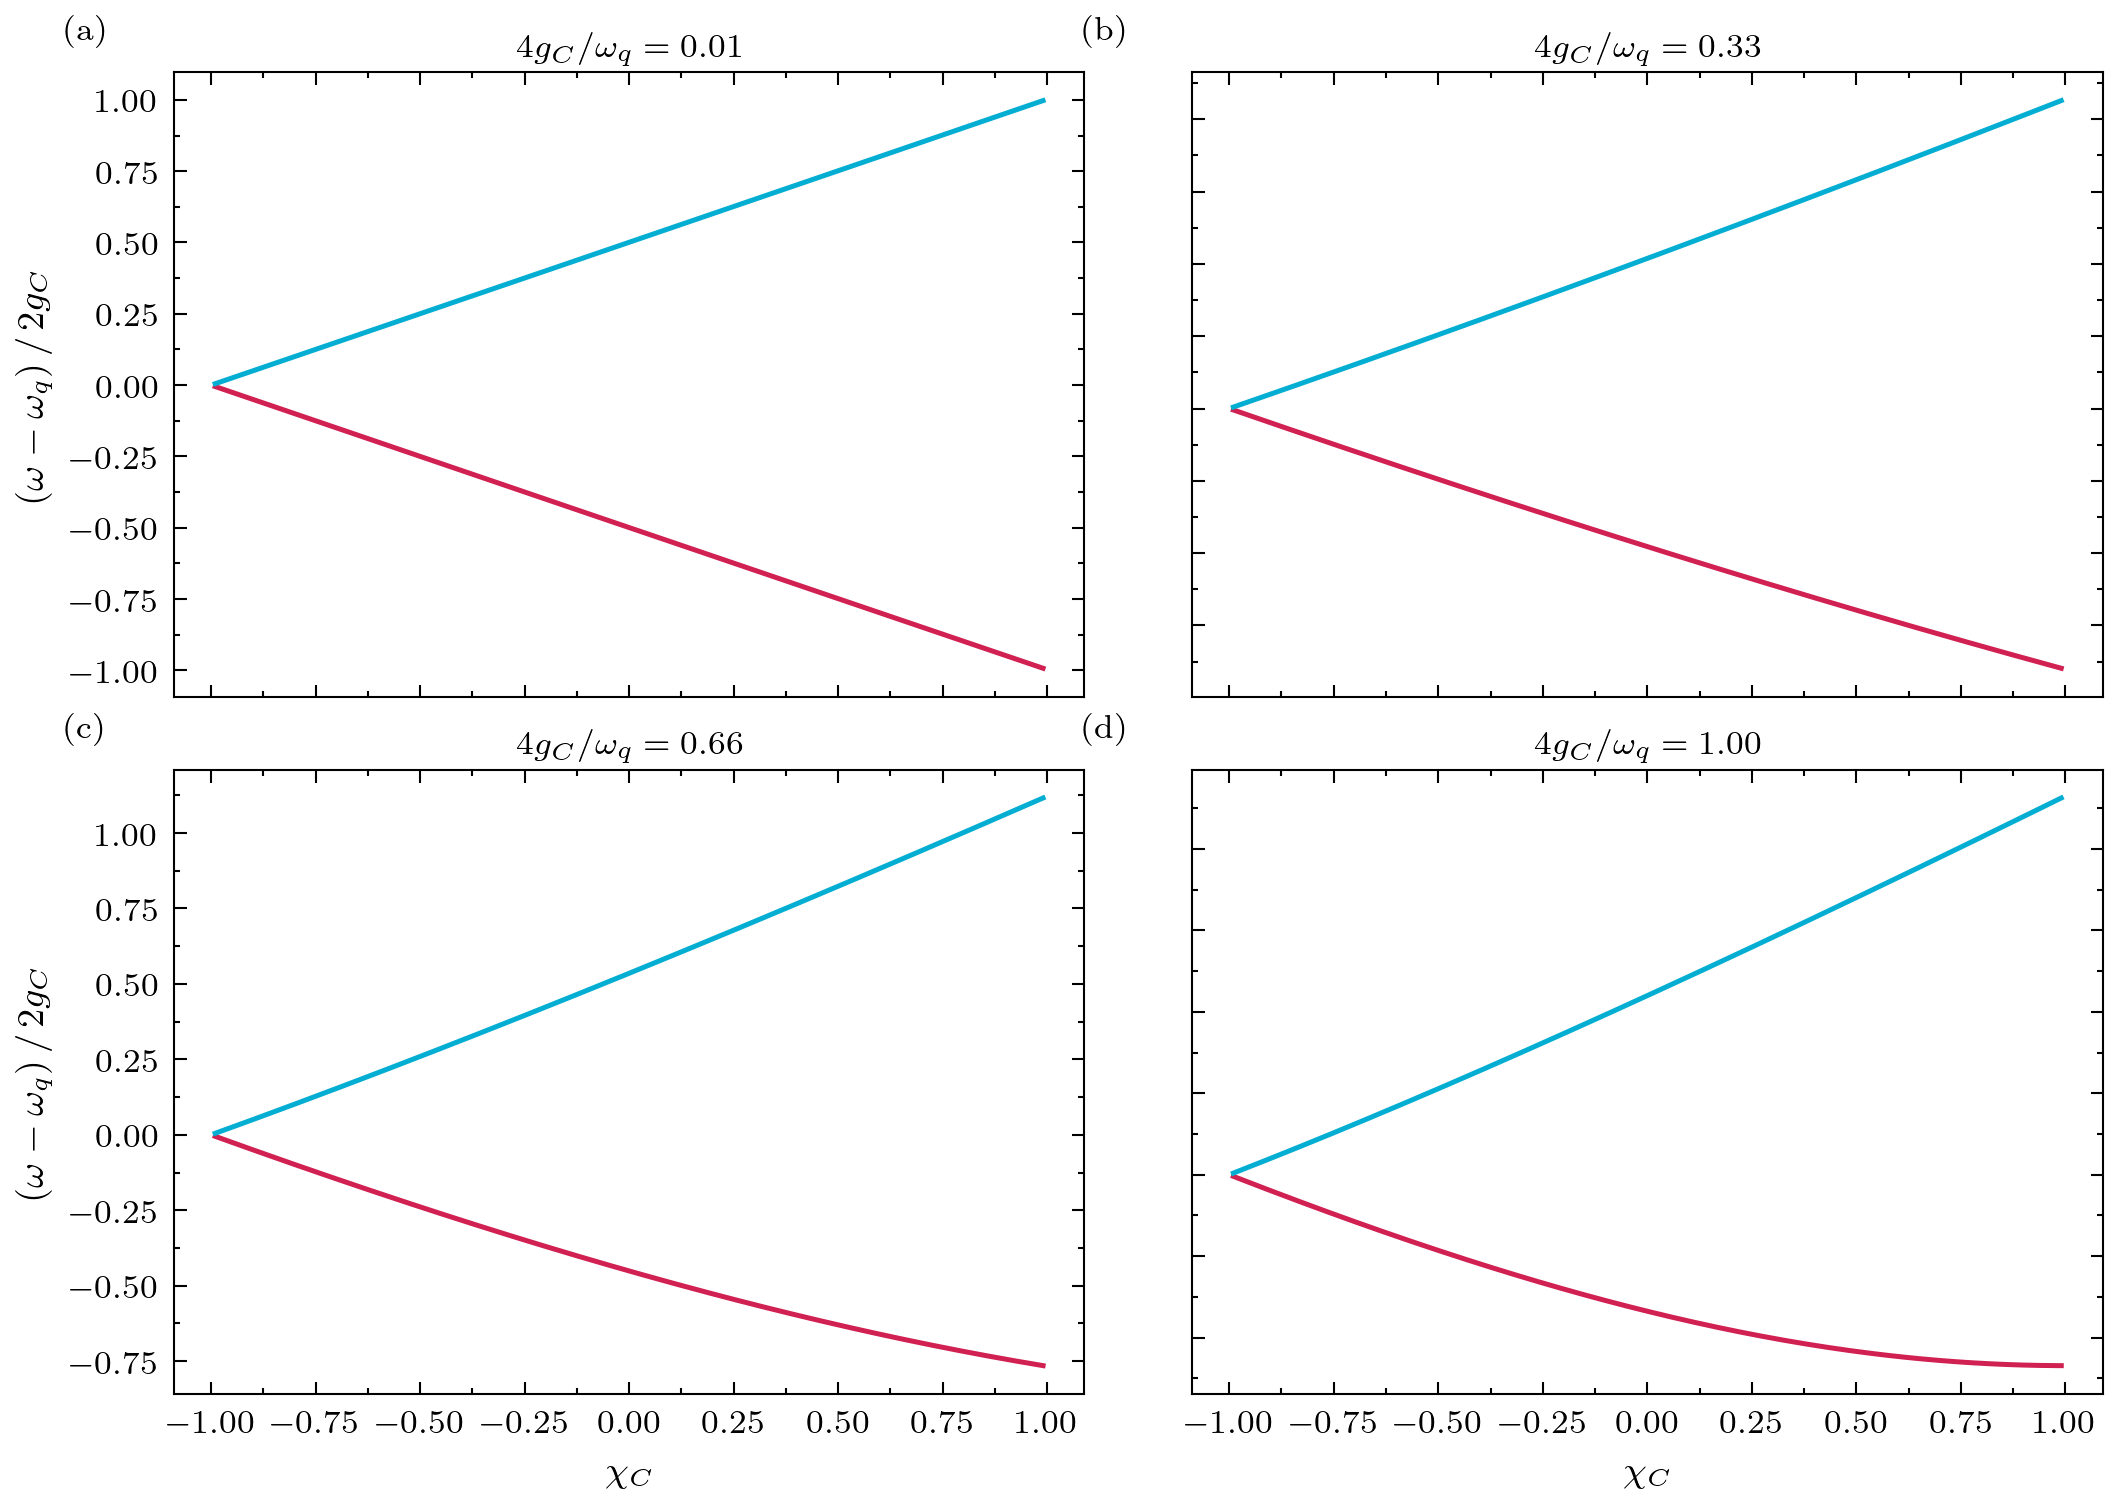

In [243]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Computer Modern Roman'],
    'text.usetex':       True,
    'font.size':         9,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'axes.linewidth':    0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.minor.size':  1.5,
    'ytick.minor.size':  1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'figure.dpi':        300,
})

colors  = ['#03AED2', '#D12052', '#F8DE22', '#F45B26']

# ------------------------------------------------------------------ #The van Hemmen paper actually confirms this — his eq. (26) writes D=(ABBA)D=(AB​BA​) (for 
# Parameters
# ------------------------------------------------------------------ #
N             = 1
Omega_C_values = [0.01, 0.33, 0.66, 1.0]   # four panels
Chi_C_values  = np.linspace(-0.99, 0.99, 150)

nrows, ncols  = 2, 2
fig_width     = 7.0
fig_height    = 5.0
panel_fontsize = 8

# ------------------------------------------------------------------ #
# Compute spectra
# ------------------------------------------------------------------ #
all_energies = []
for Omega_C in Omega_C_values:
    energies = []
    for Chi_C in Chi_C_values:
        chain = OBCSSHChain(N=N, omega_c=Omega_C, chi_c=Chi_C)
        vals, _ = chain.eigs()
        energies.append(vals)
    all_energies.append(np.array(energies))

# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(fig_width, fig_height))

for idx, (Omega_C, energies) in enumerate(zip(Omega_C_values, all_energies)):
    ax  = axes.flatten()[idx]
    row = idx // ncols
    col = idx  % ncols

    scaled = 2.0 * (energies - 1.0) / Omega_C
    edge_thresh = 0.1

    for band in scaled.T:
        mean_val = np.mean(band)
        edge_val = np.mean(np.abs([band[0], band[-1]]))

        if idx == len(Omega_C_values) - 1 and edge_val < edge_thresh:
            color = colors[1]
        elif mean_val < 0:
            color = colors[1]
        else:
            color = colors[0]

        ax.plot(Chi_C_values, band, color=color, lw=1.2)  # ← this was missing

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.text(-0.12, 1.04, f'({chr(97 + idx)})',
            transform=ax.transAxes,
            fontsize=panel_fontsize, fontweight='bold',
            va='bottom', ha='left')

    ax.set_title(rf'$4g_C / \omega_q = {Omega_C:.2f}$', fontsize=8, pad=4)

    if row == nrows - 1:
        ax.set_xlabel(r'$\chi_C$')
    else:
        ax.tick_params(labelbottom=False)

    if col == 0:
        ax.set_ylabel(r'$(\omega - \omega_q)\,/\,2g_C$')
    else:
        ax.tick_params(labelleft=False)

fig.tight_layout(pad=0.4, h_pad=0.5, w_pad=0.5)
# plt.savefig('../../../figures/export/obc_bands.pdf', dpi = 600)
plt.show()

In [ ]:
def ssh_energies(band, omega_q, gc1, gc2, k):
    delta = np.sqrt(gc1**2 + gc2**2 + 2 * gc1 * gc2 * np.cos(k))
    if band == 0:
        energy = omega_q * np.sqrt(1 + 2 * delta / omega_q)
    elif band == 1:
        energy = omega_q * np.sqrt(1 - 2 * delta / omega_q)
        
    return energy

def non_pairing_ssh_energies(band, omega_q, gc1, gc2, k):
    delta = np.sqrt(gc1**2 + gc2**2 + 2 * gc1 * gc2 * np.cos(k))
    if band == 0:
        energy = omega_q  + delta 
    elif band == 1:
        energy =  omega_q  - delta
        
    return energy


class PBCSSHChain:
    def __init__(self, N, omega_c, chi_c):
        if N == 1:
            self.N = N
            self.omega_c = omega_c
            self.chi_c = chi_c
            g = 0.25 * omega_c * (1 + chi_c)
            self.g1 = g
            self.g2 = 0
            
            A = 0.5 * sp.eye(2) + 0.5 * sp.csr_matrix(
                    [[0, g],
                    [g, 0]])
            
            B = -0.5 * sp.csr_matrix(
                    [[0, g],
                    [g, 0]])
            
            self.H = sp.bmat([
                        [ A,  B],
                        [-B, -A]
                        ], format='csr')
            return
        
        
        self.N = N
        self.omega_c = omega_c
        self.chi_c = chi_c

        g1 = 0.25 * omega_c * (1 + chi_c)
        g2 = 0.25 * omega_c * (1 - chi_c)
        self.g1 = g1
        self.g2 = g2
        
        sup_diag = sp.diags(
            [g1 if j % 2 == 0 else g2 for j in range(2 * N - 1)],
            offsets=1,
            shape=(2 * N, 2 * N)
        )
        sub_diag = sup_diag.T
        main_diag = sp.eye(2 * N)

        A = 0.5 * (main_diag + sup_diag + sub_diag)
        B = 0.5 * (sup_diag + sub_diag)   


        # Convert to LIL for item assignment
        A = A.tolil()
        B = B.tolil()

        A[0, 2*N-1] = 0.5 * g2
        A[2*N-1, 0] = 0.5 * g2
        B[2*N-1, 0]  = 0.5 * g2
        B[0, 2*N-1]  = 0.5 * g2

        # Convert back to CSR for bmat
        A = A.tocsr()
        B = B.tocsr()
        self.H = sp.bmat([
            [ A, B],
            [-B, -A]
        ], format='csr')

    def eigs(self):
        vals, vecs = np.linalg.eigh(self.H.toarray())
        vals_pos = vals[2*self.N:] * 2.0
        vecs_pos = vecs[:, 2*self.N:]
        return vals_pos, vecs_pos

    def analytical_energies(self):
        if self.N != 1:
            k_values = np.fft.fftshift(np.fft.fftfreq(self.N, d=1.0/(2*np.pi)))
            alpha_energies = ssh_energies(0, 1.0, self.g1, self.g2, k_values)
            beta_energies  = ssh_energies(1, 1.0, self.g1, self.g2, k_values)
        else:
            alpha_energies = ssh_energies(0, 1.0, self.g1, 0.0, 0)
            beta_energies  = ssh_energies(1, 1.0, self.g1, 0.0, 0)
        
        return np.atleast_1d(alpha_energies), np.atleast_1d(beta_energies)
    
class NONPAIRINGPBCSSHChain:
    def __init__(self, N, omega_c, chi_c):
        self.N = N
        self.omega_c = omega_c
        self.chi_c = chi_c

        g1 = 0.25 * omega_c * (1 + chi_c)
        g2 = 0.25 * omega_c * (1 - chi_c)
        self.g1 = g1
        self.g2 = g2
        
        sup_diag = sp.diags(
            [g1 if j % 2 == 0 else g2 for j in range(2 * N - 1)],
            offsets=1,
            shape=(2 * N, 2 * N)
        )
        sub_diag = sup_diag.T
        main_diag = sp.eye(2 * N)

        A = 0.5 * (main_diag + sup_diag + sub_diag)
        B = -0.0 * (sup_diag + sub_diag)   


        # Convert to LIL for item assignment
        A = A.tolil()
        B = B.tolil()

        A[0, 2*N-1] = 0.5 * g2
        A[2*N-1, 0] = 0.5 * g2
        B[2*N-1, 0]  = -0.0 * g2
        B[0, 2*N-1]  = -0.0 * g2

        # Convert back to CSR for bmat
        A = A.tocsr()
        B = B.tocsr()
        self.H = sp.bmat([
            [ A, B],
            [-B, -A]
        ], format='csr')

    def eigs(self):
        vals, vecs = np.linalg.eigh(self.H.toarray())
        vals_pos = vals[2*self.N:] * 2.0
        vecs_pos = vecs[:, 2*self.N:]
        return vals_pos, vecs_pos

class NONPAIRINGPBCSSHChain:
    def __init__(self, N, omega_c, chi_c):
        self.N = N
        self.omega_c = omega_c
        self.chi_c = chi_c

        g1 = 0.25 * omega_c * (1 + chi_c)

    def analytical_energies(self):
        if self.N != 1:
            k_values = np.fft.fftshift(np.fft.fftfreq(self.N, d=1.0/(2*np.pi)))
            alpha_energies = non_pairing_ssh_energies(0, 1.0, self.g1, self.g2, k_values)
            beta_energies  = non_pairing_ssh_energies(1, 1.0, self.g1, self.g2, k_values)
        else:
            alpha_energies = non_pairing_ssh_energies(0, 1.0, self.g1, 0.0, 0)
            beta_energies  = non_pairing_ssh_energies(1, 1.0, self.g1, 0.0, 0)
        
        return np.atleast_1d(alpha_energies), np.atleast_1d(beta_energies)

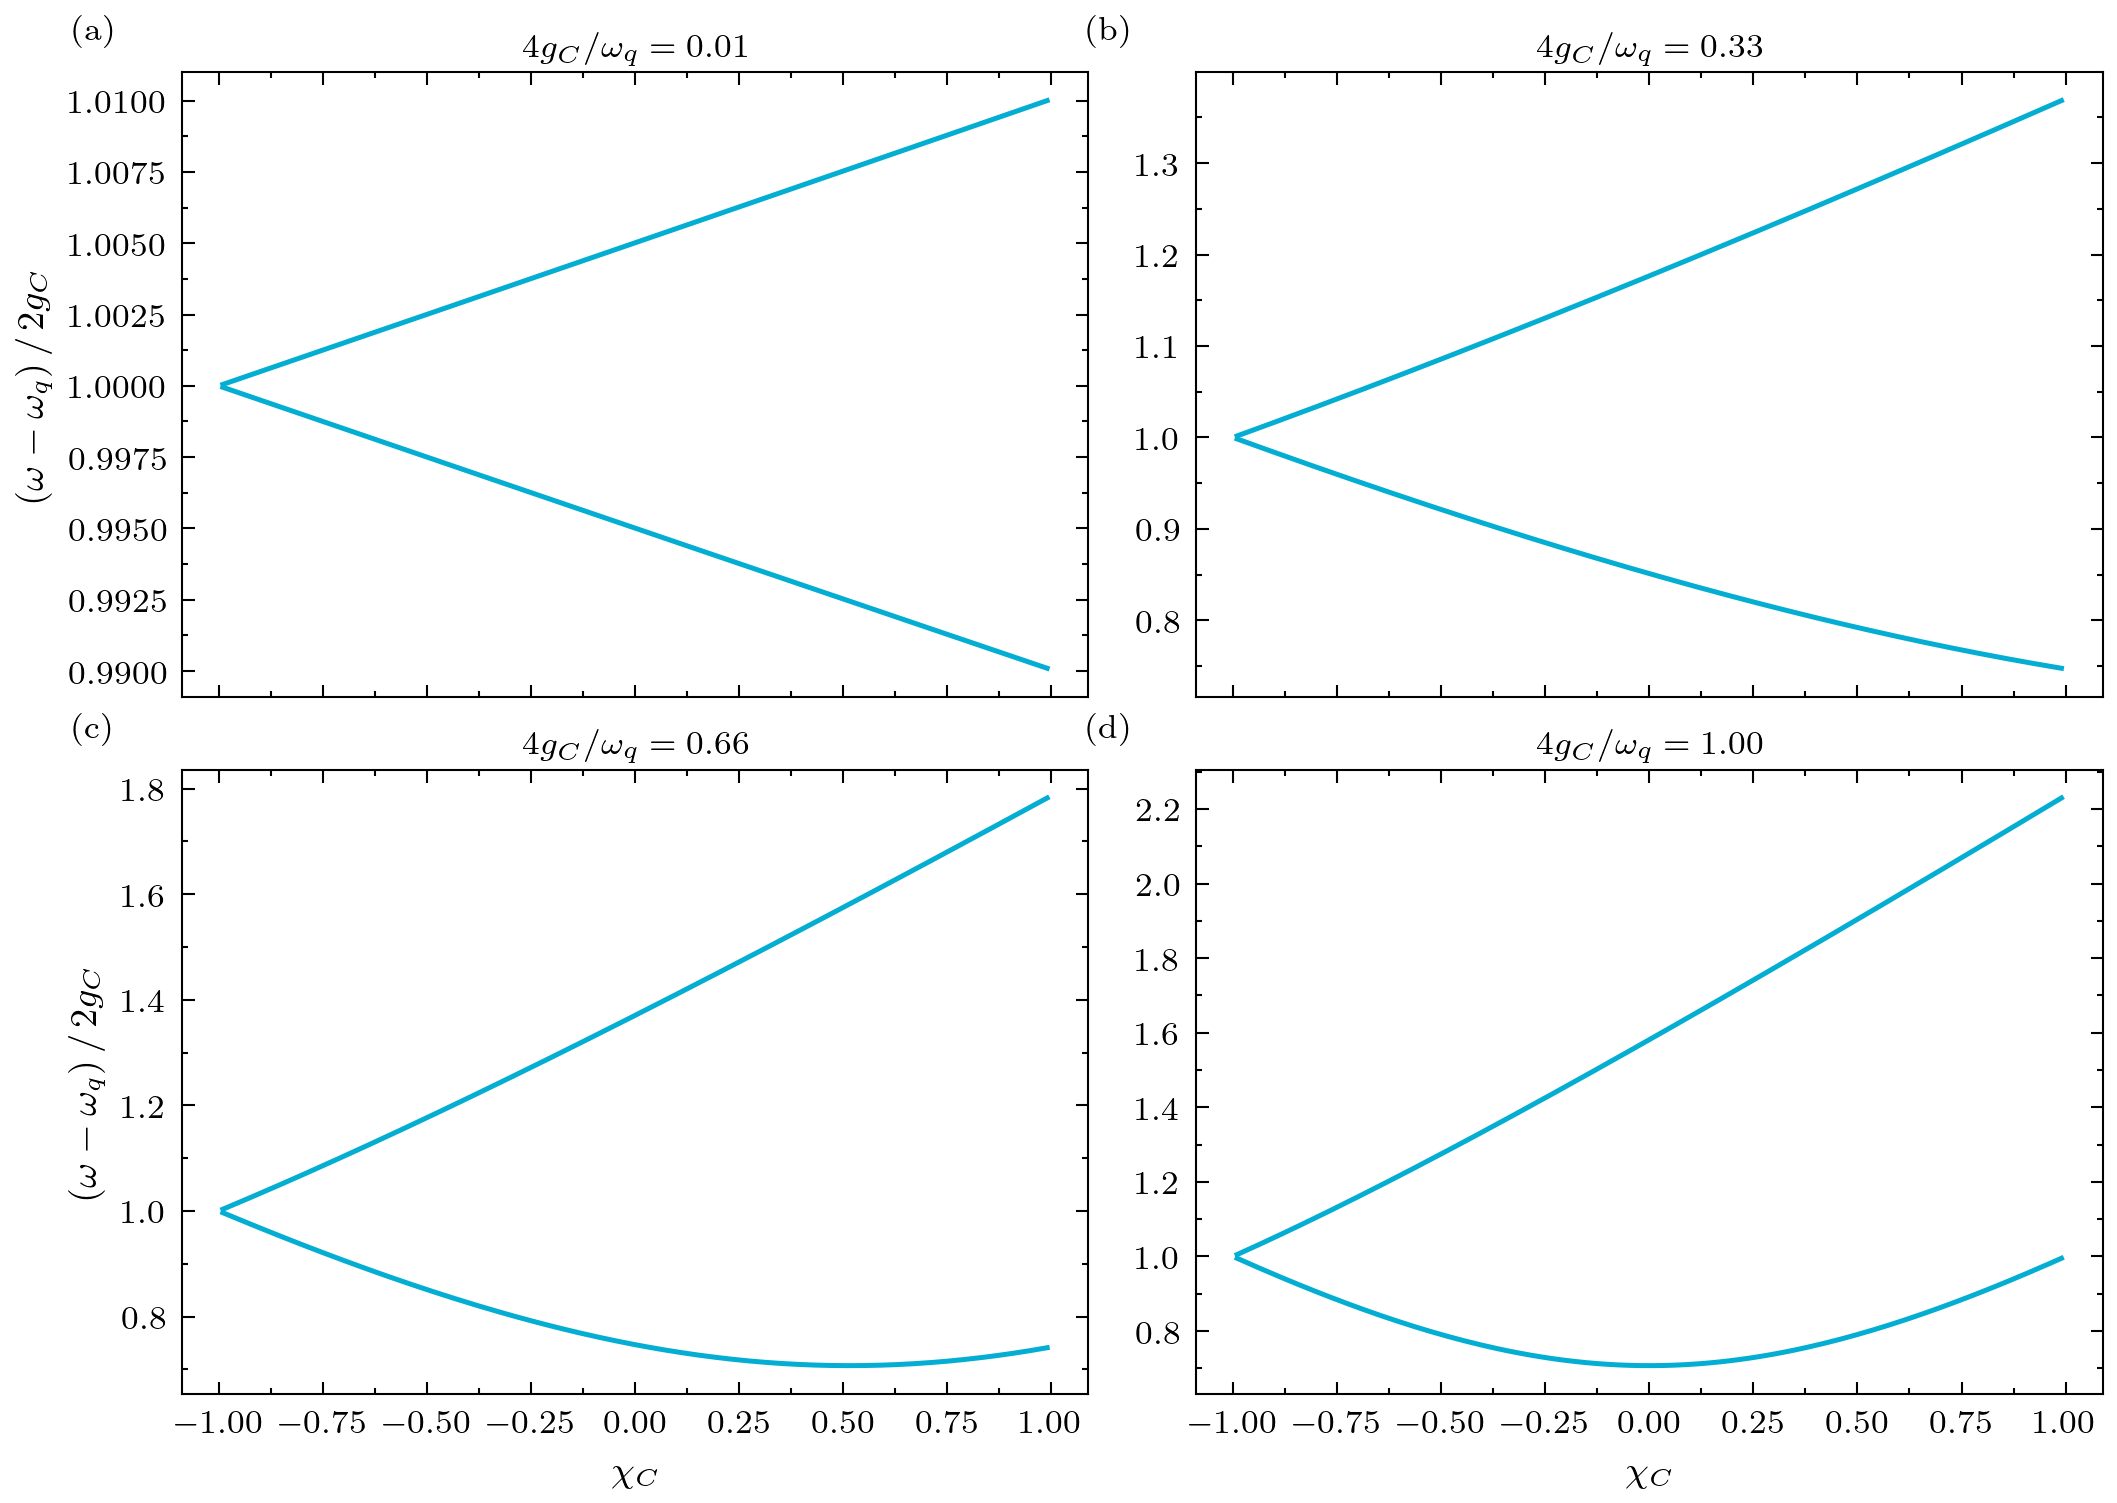

In [247]:
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N             = 1
Omega_C_values = [0.01, 0.33, 0.66, 1.0]   # four panels
Chi_C_values  = np.linspace(-0.99, 0.99, 150)

nrows, ncols  = 2, 2
fig_width     = 7.0
fig_height    = 5.0
panel_fontsize = 8

# ------------------------------------------------------------------ #
# Compute spectra
# ------------------------------------------------------------------ #
all_energies = []
for Omega_C in Omega_C_values:
    energies = []
    for Chi_C in Chi_C_values:
        chain = PBCSSHChain(N=N, omega_c=Omega_C, chi_c=Chi_C)
        vals, _ = chain.eigs()
        energies.append(vals)
    all_energies.append(np.array(energies))

# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(fig_width, fig_height))

for idx, (Omega_C, energies) in enumerate(zip(Omega_C_values, all_energies)):
    ax  = axes.flatten()[idx]
    row = idx // ncols
    col = idx  % ncols

    # scaled = 2.0 * (energies - 1.0) / Omega_C
    scaled = energies
    edge_thresh = 0.1

    for band in scaled.T:
        mean_val = np.mean(band)
        edge_val = np.mean(np.abs([band[0], band[-1]]))

        if idx == len(Omega_C_values) - 1 and edge_val < edge_thresh:
            color = colors[1]
        elif mean_val < 0:
            color = colors[1]
        else:
            color = colors[0]

        ax.plot(Chi_C_values, band, color=color, lw=1.2)  # ← this was missing

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.text(-0.12, 1.04, f'({chr(97 + idx)})',
            transform=ax.transAxes,
            fontsize=panel_fontsize, fontweight='bold',
            va='bottom', ha='left')

    ax.set_title(rf'$4g_C / \omega_q = {Omega_C:.2f}$', fontsize=8, pad=4)

    if row == nrows - 1:
        ax.set_xlabel(r'$\chi_C$')
    else:
        ax.tick_params(labelbottom=False)

    if col == 0:
        ax.set_ylabel(r'$(\omega - \omega_q)\,/\,2g_C$')
    # else:
    #     ax.tick_params(labelleft=False)

fig.tight_layout(pad=0.4, h_pad=0.5, w_pad=0.5)
# plt.savefig('../../../figures/export/obc_bands.pdf', dpi = 600)
plt.show()

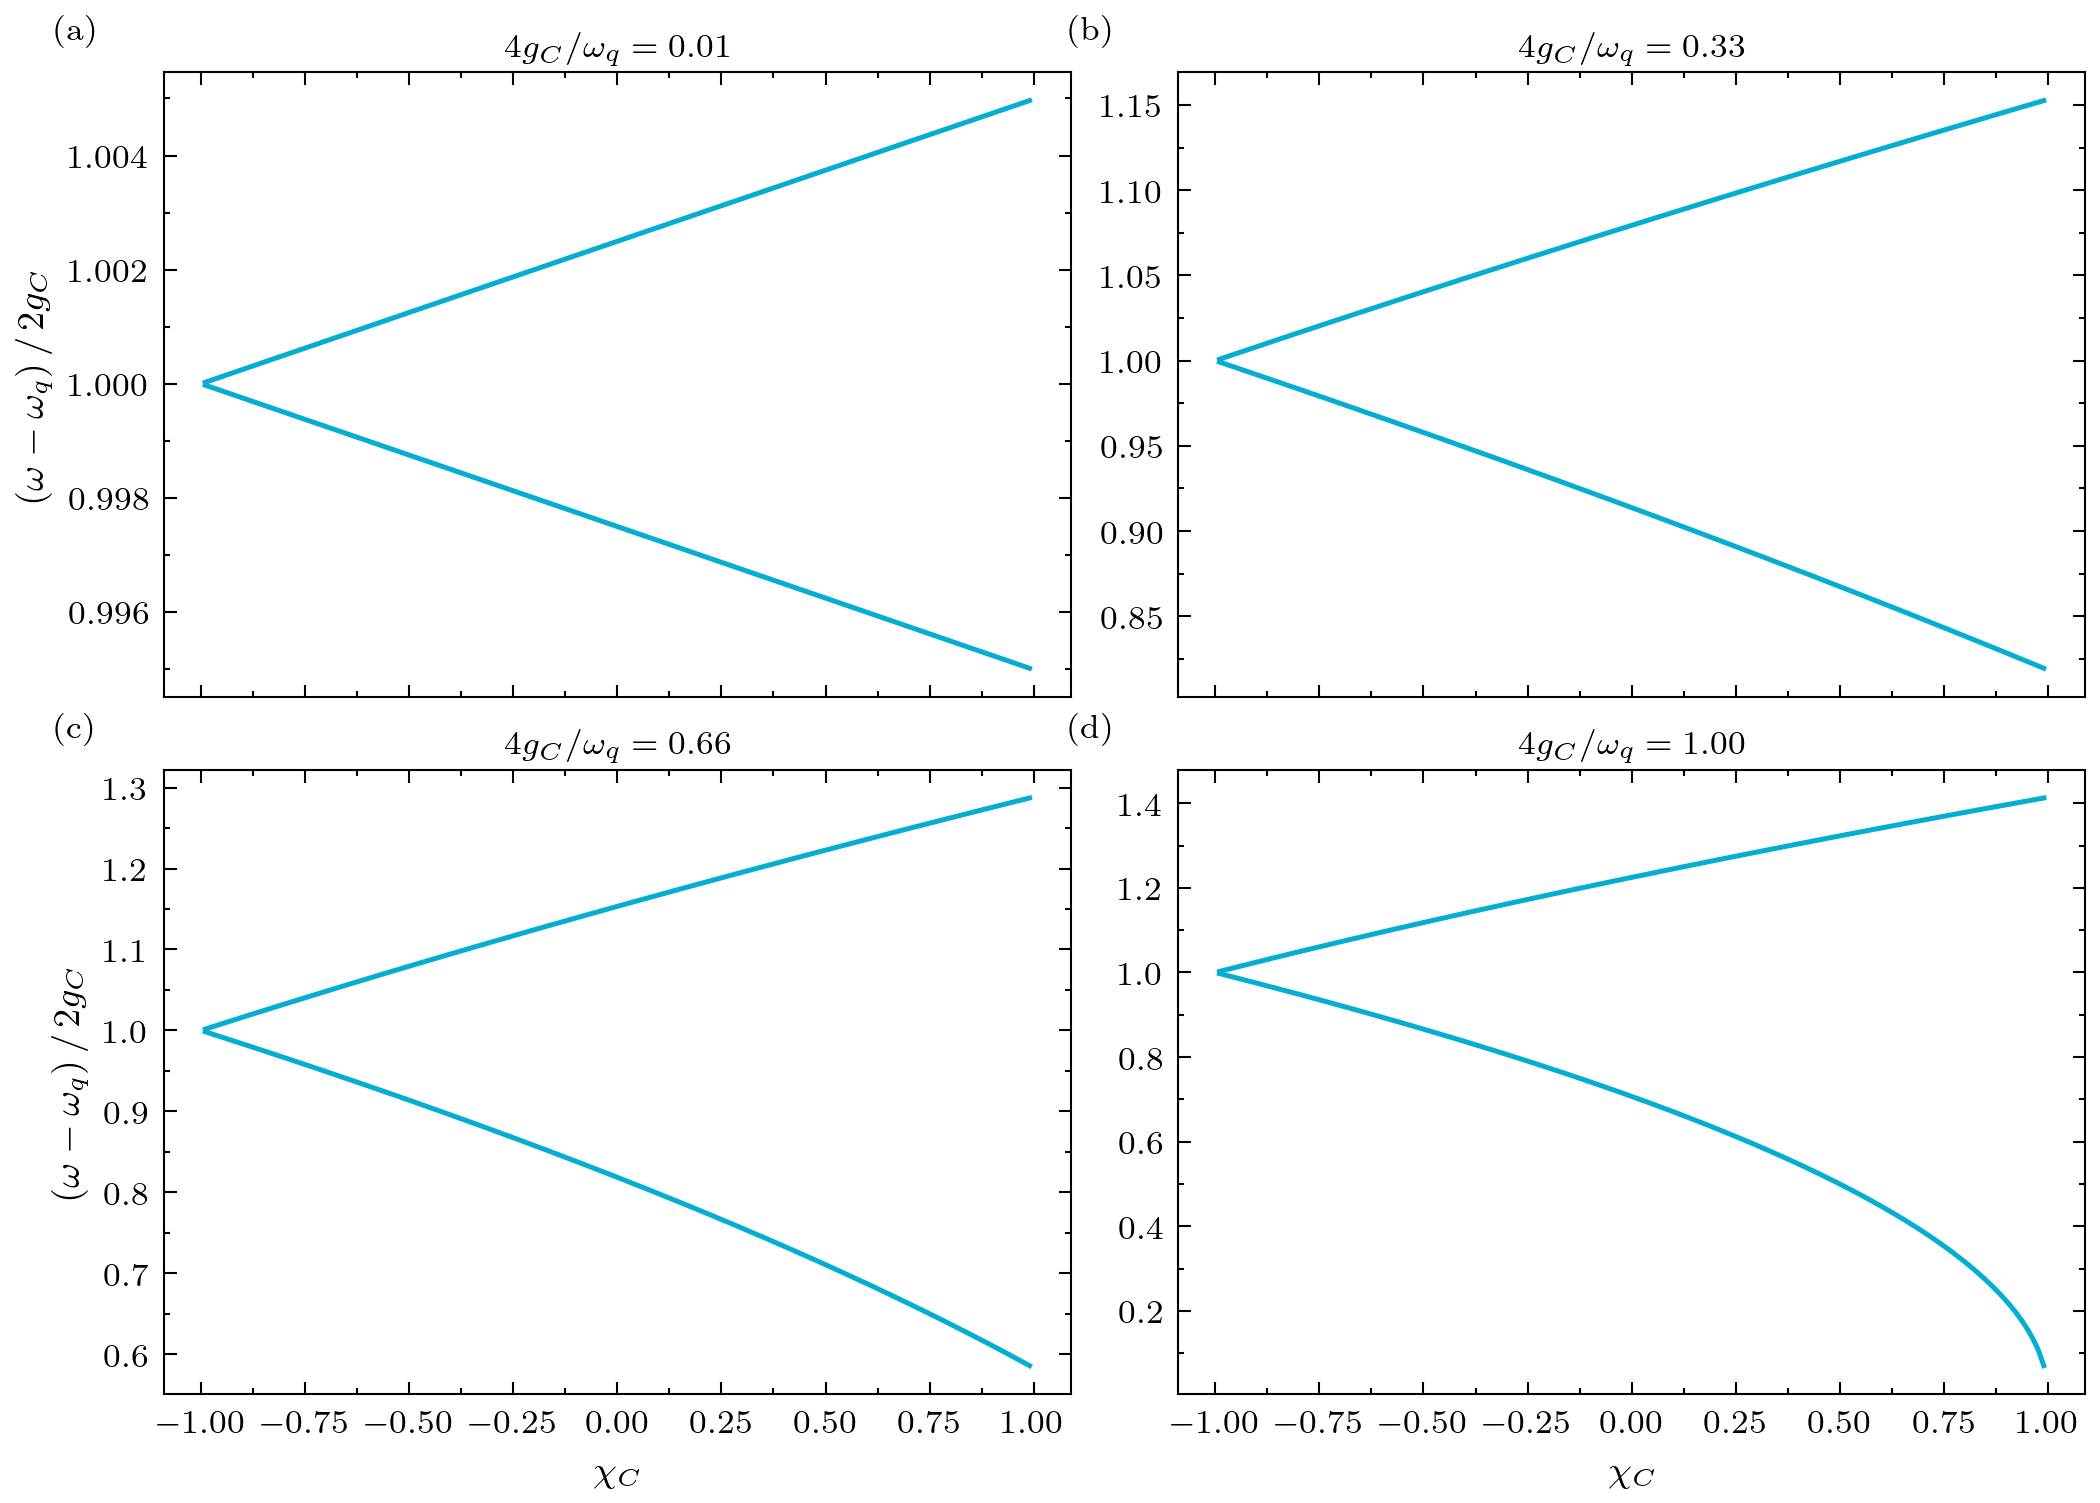

In [241]:
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N             = 1
Omega_C_values = [0.01, 0.33, 0.66, 1.0]   # four panels
Chi_C_values  = np.linspace(-0.99, 0.99, 150)

nrows, ncols  = 2, 2
fig_width     = 7.0
fig_height    = 5.0
panel_fontsize = 8

# ------------------------------------------------------------------ #
# Compute spectra
# ------------------------------------------------------------------ #
all_energies = []
for Omega_C in Omega_C_values:
    energies = []
    for Chi_C in Chi_C_values:
        chain = PBCSSHChain(N=N, omega_c=Omega_C, chi_c=Chi_C)
        alpha_energies, beta_energies = chain.analytical_energies()
        energies.append(np.concatenate((alpha_energies, beta_energies)))
    all_energies.append(np.array(energies))

# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(fig_width, fig_height))

for idx, (Omega_C, energies) in enumerate(zip(Omega_C_values, all_energies)):
    ax  = axes.flatten()[idx]
    row = idx // ncols
    col = idx  % ncols

    # scaled = 2.0 * (energies - 1.0) / Omega_C
    scaled = energies
    edge_thresh = 0.1

    for band in scaled.T:
        mean_val = np.mean(band)
        edge_val = np.mean(np.abs([band[0], band[-1]]))

        if idx == len(Omega_C_values) - 1 and edge_val < edge_thresh:
            color = colors[1]
        elif mean_val < 0:
            color = colors[1]
        else:
            color = colors[0]

        ax.plot(Chi_C_values, band, color=color, lw=1.2)  # ← this was missing

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.text(-0.12, 1.04, f'({chr(97 + idx)})',
            transform=ax.transAxes,
            fontsize=panel_fontsize, fontweight='bold',
            va='bottom', ha='left')

    ax.set_title(rf'$4g_C / \omega_q = {Omega_C:.2f}$', fontsize=8, pad=4)

    if row == nrows - 1:
        ax.set_xlabel(r'$\chi_C$')
    else:
        ax.tick_params(labelbottom=False)

    if col == 0:
        ax.set_ylabel(r'$(\omega - \omega_q)\,/\,2g_C$')
    # else:
    #     ax.tick_params(labelleft=False)

fig.tight_layout(pad=0.4, h_pad=0.5, w_pad=0.5)
# plt.savefig('../../../figures/export/obc_bands.pdf', dpi = 600)
plt.show()

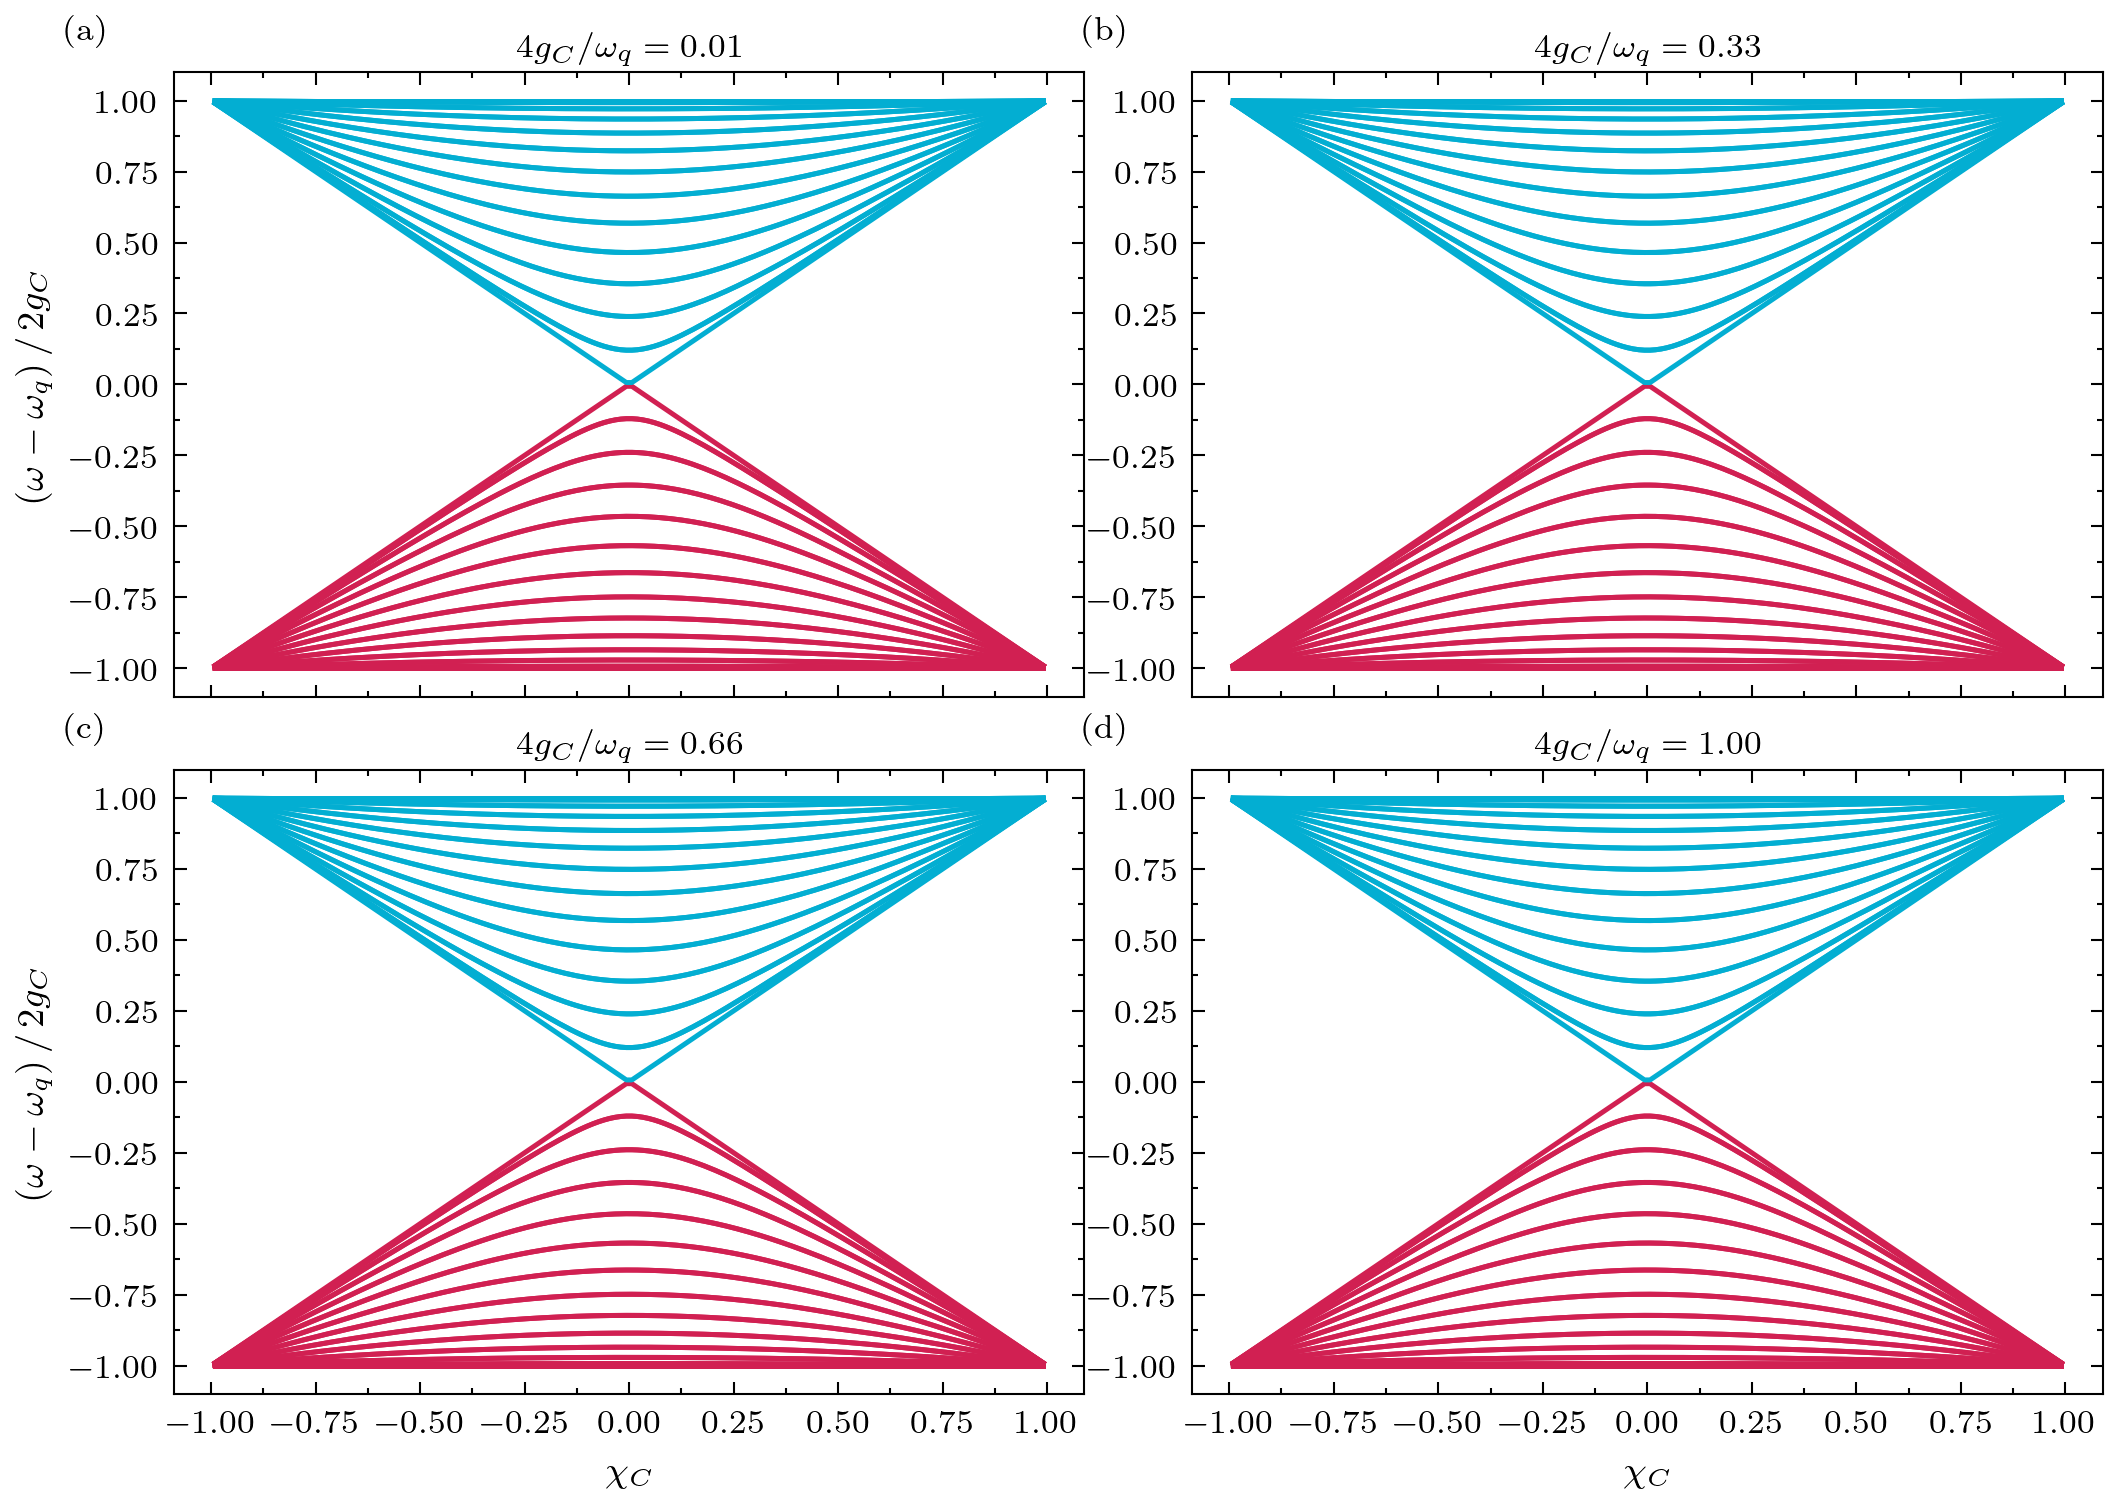

In [234]:
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N             = 26
Omega_C_values = [0.01, 0.33, 0.66, 1.0]   # four panels
Chi_C_values  = np.linspace(-0.99, 0.99, 150)

nrows, ncols  = 2, 2
fig_width     = 7.0
fig_height    = 5.0
panel_fontsize = 8

# ------------------------------------------------------------------ #
# Compute spectra
# ------------------------------------------------------------------ #
all_energies = []
for Omega_C in Omega_C_values:
    energies = []
    for Chi_C in Chi_C_values:
        chain = NONPAIRINGPBCSSHChain(N=N, omega_c=Omega_C, chi_c=Chi_C)
        vals, _ = chain.eigs()
        energies.append(vals)
    all_energies.append(np.array(energies))

# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(fig_width, fig_height))

for idx, (Omega_C, energies) in enumerate(zip(Omega_C_values, all_energies)):
    ax  = axes.flatten()[idx]
    row = idx // ncols
    col = idx  % ncols

    scaled = 2.0 * (energies - 1.0) / Omega_C
    edge_thresh = 0.1

    for band in scaled.T:
        mean_val = np.mean(band)
        edge_val = np.mean(np.abs([band[0], band[-1]]))

        if idx == len(Omega_C_values) - 1 and edge_val < edge_thresh:
            color = colors[1]
        elif mean_val < 0:
            color = colors[1]
        else:
            color = colors[0]

        ax.plot(Chi_C_values, band, color=color, lw=1.2)  # ← this was missing

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.text(-0.12, 1.04, f'({chr(97 + idx)})',
            transform=ax.transAxes,
            fontsize=panel_fontsize, fontweight='bold',
            va='bottom', ha='left')

    ax.set_title(rf'$4g_C / \omega_q = {Omega_C:.2f}$', fontsize=8, pad=4)

    if row == nrows - 1:
        ax.set_xlabel(r'$\chi_C$')
    else:
        ax.tick_params(labelbottom=False)

    if col == 0:
        ax.set_ylabel(r'$(\omega - \omega_q)\,/\,2g_C$')
    # else:
    #     ax.tick_params(labelleft=False)

fig.tight_layout(pad=0.4, h_pad=0.5, w_pad=0.5)
# plt.savefig('../../../figures/export/obc_bands.pdf', dpi = 600)
plt.show()